In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, cache_dir='.', untar=True)

In [3]:
data_dir

'.\\datasets\\flower_photos'

In [4]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [5]:
image_count = len(list(data_dir.rglob('*/*.jpg')))
image_count

3670

In [6]:
roses = list(data_dir.rglob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

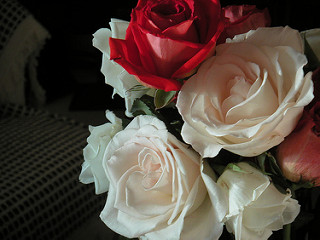

In [7]:
PIL.Image.open(str(roses[1]))

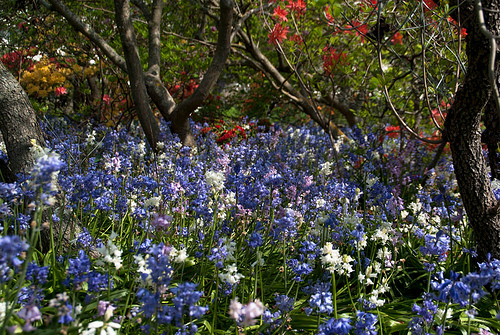

In [8]:
tulips = list(data_dir.rglob('tulips/*'))
PIL.Image.open(str(tulips[1]))

In [9]:
flowers_images_dict = {
    'roses': list(data_dir.rglob('roses/*')),
    'daisy': list(data_dir.rglob('daisy/*')),
    'dandelion': list(data_dir.rglob('dandelion/*')),
    'sunflower': list(data_dir.rglob('sunflowers/*')),
    'tulips': list(data_dir.rglob('tulips/*'))
}

In [10]:
flowers_images_dict['roses']

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/11102341464_508d558dfc_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/11233672494_d8bf0a3dbf_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/11694025703_9a906fedc1_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/118974357_0faa23cce9_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/11944957684_2cc806276e.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/12045735155_42547ce4e9_n.jpg'),
 WindowsPath('datasets/flower_p

In [11]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflower': 3,
    'tulips': 4
}

In [12]:
flowers_images_dict['roses'][0]

WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg')

In [13]:
img = cv2.imread(flowers_images_dict['roses'][0])
img.shape

(240, 179, 3)

In [14]:
cv2.resize(img, (180,180)).shape

(180, 180, 3)

In [15]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    print(flower_name)
    print(len(images))
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img, (180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

roses
641
daisy
633
dandelion
898
sunflower
699
tulips
799


In [16]:
y[:5]

[0, 0, 0, 0, 0]

In [17]:
X[0]

array([[[ 1, 16,  7],
        [ 1, 16,  7],
        [ 1, 17,  9],
        ...,
        [23, 50, 31],
        [25, 51, 32],
        [26, 52, 33]],

       [[10, 23, 15],
        [10, 23, 15],
        [ 9, 22, 14],
        ...,
        [20, 44, 30],
        [23, 47, 33],
        [26, 50, 36]],

       [[13, 20, 13],
        [12, 20, 13],
        [11, 19, 12],
        ...,
        [21, 43, 30],
        [22, 45, 31],
        [25, 48, 34]],

       ...,

       [[12, 24, 18],
        [11, 22, 15],
        [12, 21, 11],
        ...,
        [ 7, 14,  7],
        [ 2,  8,  2],
        [ 0,  2,  0]],

       [[19, 30, 28],
        [16, 26, 21],
        [14, 22, 15],
        ...,
        [ 3, 12,  2],
        [ 0,  8,  1],
        [ 0,  6,  1]],

       [[11, 21, 20],
        [17, 25, 24],
        [21, 28, 23],
        ...,
        [ 1, 12,  2],
        [ 2, 10,  3],
        [ 3, 10,  4]]], shape=(180, 180, 3), dtype=uint8)

In [18]:
X = np.array(X)
y = np.array(y)

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [20]:
len(X_train)

2752

In [21]:
len(X_test)

918

In [22]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [23]:
X_train_scaled[0]

array([[[0.26666667, 0.30980392, 0.30196078],
        [0.24705882, 0.2745098 , 0.24705882],
        [0.23529412, 0.24313725, 0.21960784],
        ...,
        [0.19215686, 0.15686275, 0.14509804],
        [0.18823529, 0.15294118, 0.14117647],
        [0.18823529, 0.15294118, 0.14117647]],

       [[0.22352941, 0.24313725, 0.23529412],
        [0.23921569, 0.25098039, 0.23529412],
        [0.23529412, 0.23921569, 0.21568627],
        ...,
        [0.18823529, 0.15294118, 0.14117647],
        [0.18823529, 0.15294118, 0.14117647],
        [0.19607843, 0.16078431, 0.14901961]],

       [[0.23921569, 0.22745098, 0.22352941],
        [0.25098039, 0.25098039, 0.23137255],
        [0.23137255, 0.23137255, 0.20784314],
        ...,
        [0.19215686, 0.15686275, 0.14509804],
        [0.19215686, 0.15686275, 0.14509804],
        [0.19607843, 0.16078431, 0.14901961]],

       ...,

       [[0.19215686, 0.4745098 , 0.36470588],
        [0.15686275, 0.25490196, 0.2       ],
        [0.20392157, 0

In [24]:
num_classes = 5

model = Sequential([
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.4059 - loss: 1.3558
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 71s 830ms/step - accuracy: 0.6017 - loss: 1.0195
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.6875 - loss: 0.8231
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.7871 - loss: 0.5909
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.8630 - loss: 0.4031   
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 18s 204ms/step - accuracy: 0.9306 - loss: 0.2183
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 54s 628ms/step - accuracy: 0.9669 - loss: 0.1127
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.9866 - loss: 0.0533
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9909 - loss: 0.0404
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 75s 884ms/step - accuracy: 0.9942 - loss: 0.0291
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.9902 - loss: 0.0375
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/st

In [26]:
model.evaluate(X_test_scaled, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.6797 - loss: 2.3823


[2.3822929859161377, 0.6797385811805725]

In [27]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


array([[  5.0282483 ,  37.371952  ,   4.978987  , -21.265032  ,
          3.1509635 ],
       [ 11.698362  ,   2.1802711 ,  -4.692329  ,  -3.682389  ,
         11.285659  ],
       [ -4.846408  ,  -0.7134071 ,  13.021607  ,  -6.397519  ,
         -4.2345695 ],
       ...,
       [  4.9209733 ,  -2.6333275 ,  -5.521559  ,  14.83504   ,
          4.437759  ],
       [  8.887382  ,   6.0144005 ,   0.11228336,   3.848329  ,
          0.23687524],
       [ -0.28781042,  -9.69216   ,   0.44254625,  13.363052  ,
          5.0489807 ]], shape=(918, 5), dtype=float32)

In [29]:
score = tf.nn.softmax(predictions[0])
score

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([8.980650e-15, 1.000000e+00, 8.548989e-15, 3.422006e-26,
       1.374084e-15], dtype=float32)>

In [30]:
np.argmax(score)

np.int64(1)

In [31]:
y_test[0]

np.int64(1)

In [48]:
data_augmentation = keras.Sequential([
    layers.InputLayer(input_shape=(180, 180, 3)),
    layers.RandomZoom(0.3)
])

d:\Work\On\.PRACTISE\Learn\deep-learning-with-Tensorflow\.venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


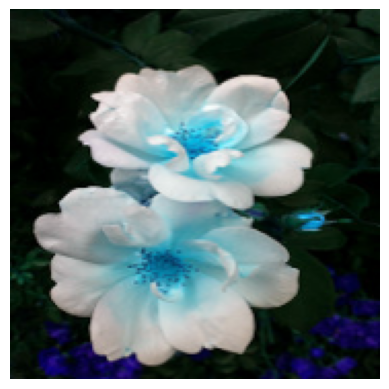

In [35]:
plt.axis('off')
plt.imshow(X[0])

In [42]:
data_augmentation(X[0])

<tf.Tensor: shape=(180, 180, 3), dtype=float32, numpy=
array([[[13.356514  , 25.365955  , 12.59857   ],
        [13.1328335 , 24.422932  , 12.244674  ],
        [12.322569  , 23.801968  , 11.812109  ],
        ...,
        [15.811607  , 33.777668  , 17.178257  ],
        [17.455597  , 35.50412   , 18.50412   ],
        [19.073238  , 37.42031   , 20.420307  ]],

       [[ 8.982742  , 19.295868  ,  8.955914  ],
        [ 8.426164  , 18.079868  ,  8.094583  ],
        [ 7.1969037 , 17.185925  ,  7.2696    ],
        ...,
        [15.932448  , 32.52672   , 16.399017  ],
        [18.322124  , 35.381504  , 19.124018  ],
        [20.375105  , 37.718857  , 21.535467  ]],

       [[ 3.3531234 , 11.164724  ,  4.431792  ],
        [ 3.        , 10.732933  ,  3.7641456 ],
        [ 2.7685955 , 10.483698  ,  3.1157022 ],
        ...,
        [16.777721  , 32.52849   , 17.777721  ],
        [19.99504   , 35.32808   , 21.092228  ],
        [21.30127   , 36.866596  , 22.866592  ]],

       ...,

     

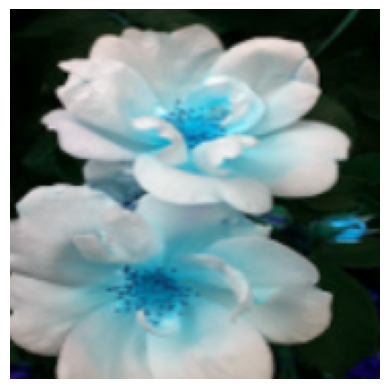

In [49]:
plt.axis('off')
import tensorflow as tf
augmented = data_augmentation(tf.expand_dims(X[0], 0))
plt.imshow(augmented[0].numpy().astype('uint8'))

In [51]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal",
                      input_shape=(180, 180, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

d:\Work\On\.PRACTISE\Learn\deep-learning-with-Tensorflow\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
num_classes = 5

model = Sequential([
    data_augmentation,
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 191ms/step - accuracy: 0.3110 - loss: 1.6055
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 17s 198ms/step - accuracy: 0.4680 - loss: 1.2757
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 286ms/step - accuracy: 0.5836 - loss: 1.0552
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 290ms/step - accuracy: 0.6163 - loss: 0.9835
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 14s 157ms/step - accuracy: 0.6537 - loss: 0.8947
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - accuracy: 0.6719 - loss: 0.8355
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.6919 - loss: 0.8070
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 148ms/step - accuracy: 0.7006 - loss: 0.7722
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.7184 - loss: 0.7252
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.7355 - loss: 0.6876
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 13s 146ms/step - accuracy: 0.7409 - loss: 0.6692
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 12

In [53]:
model.evaluate(X_test_scaled, y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7288 - loss: 0.9188


[0.9188259243965149, 0.7287581562995911]